In [11]:
import os 
import random
import numpy as np
import pandas as pd
import xgboost as xgb
import lightgbm as lgb
from sklearn.svm import SVC
from sklearn.ensemble import VotingClassifier
from sklearn.ensemble import StackingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, confusion_matrix

import matplotlib.pyplot as plt

import torch
import torch.nn as nn 
import torch.optim as optim 
import torch.nn.functional as F

# import tensor dataset & data loader
from torch.utils.data import TensorDataset, DataLoader

%matplotlib inline

In [12]:
# Define the seed

def set_seed(seed: int):
    random.seed(seed) # Python
    np.random.seed(seed)  # Numpy, é o gerador utilizado pelo sklearn
    os.environ["PYTHONHASHSEED"] = str(seed)  # sistema operativo

def set_seed(seed: int, deterministic_torch: bool = True):
    random.seed(seed) # Python
    np.random.seed(seed)  # Numpy, é o gerador utilizado pelo sklearn
    os.environ["PYTHONHASHSEED"] = str(seed)  # sistema operativo
    if torch is not None:
        torch.manual_seed(seed)
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)  #multi-GPU
        if deterministic_torch:
            torch.backends.cudnn.deterministic = True
            torch.backends.cudnn.benchmark = False

set_seed(123)
set_seed(123, deterministic_torch=True)

In [13]:
# --- Loading the train dataset
train_dataset = pd.read_csv('data/train_dataset.csv')

# --- Loading the dataset
test_dataset = pd.read_csv('data/test_dataset.csv')
    

In [14]:
# --- Defining the functions that will use the model to complete the test dataset

def complete_dataset(model_name, model):
    # Loading the test dataset
    test_dataset = pd.read_csv('data/test_dataset.csv')
    # Making the predictions
    test_pred = model.predict(test_dataset)
    test_dataset['Transition'] = test_pred
    # Dropping all columns but the Transition column
    test_dataset.drop(test_dataset.columns.difference(['Transition']), axis=1, inplace=True)
    # Creating a RowId column
    test_dataset['RowId'] = np.arange(1, test_dataset.shape[0] + 1)
    # Placing the RowId column in the first position
    cols = test_dataset.columns.tolist()
    cols = cols[-1:] + cols[:-1]
    test_dataset = test_dataset[cols]
    # Transforming the Transition column back to its original values
    replace_map = {'Transition': {1: 'CN-CN', 2: 'AD-AD', 3: 'CN-MCI', 4: 'MCI-AD', 5: 'MCI-MCI'}}
    test_dataset.replace(replace_map, inplace=True)
    test_dataset.head()
    # Saving the test dataset to a csv file
    test_dataset.to_csv('test_predictions_' + model_name + '.csv', index=False)


def complete_dataset_type2(model_name, model): # this is just used for the XGB and ANN models since they require the target values to start at 0
    # Loading the test dataset
    test_dataset = pd.read_csv('data/test_dataset.csv')
    if model_name == 'ann': 
        test_data = test_dataset.values
        test_pred = model.predict(test_data)
    else: 
        # Making the predictions
        test_pred = model.predict(test_dataset)
    test_dataset['Transition'] = test_pred
    # Dropping all columns but the Transition column
    test_dataset.drop(test_dataset.columns.difference(['Transition']), axis=1, inplace=True)
    # Creating a RowId column
    test_dataset['RowId'] = np.arange(1, test_dataset.shape[0] + 1)
    # Placing the RowId column in the first position
    cols = test_dataset.columns.tolist()
    cols = cols[-1:] + cols[:-1]
    test_dataset = test_dataset[cols]
    # Transforming the Transition column back to its original values
    replace_map = {'Transition': {0: 'CN-CN', 1: 'AD-AD', 2: 'CN-MCI', 3: 'MCI-AD', 4: 'MCI-MCI'}}
    test_dataset.replace(replace_map, inplace=True)
    test_dataset.head()
    # Saving the test dataset to a csv file
    test_dataset.to_csv('test_predictions_' + model_name + '.csv', index=False)

In [15]:
# --- Defining features and target
X = train_dataset.drop('Transition', axis=1)
y = train_dataset['Transition']

In [16]:
# Dropping the oversampled column if it exists in features
if 'oversampled' in X.columns:
    X = X.drop(columns=['oversampled'])

# dictionary to store the f1 scores of each model
results = {}

# ANN

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score
import numpy as np
import pandas as pd

# --- Implementing an ANN model

# This specific model needs the target to be encoded starting from 0
y = y.replace({1: 0, 2: 1, 3: 2, 4: 3, 5: 4})

random_state = 123

# Split into train+CV and validation sets
non_oversampled_mask = train_dataset['oversampled'] == 'NO'
X_no_oversample = X[non_oversampled_mask]
y_no_oversample = y[non_oversampled_mask]

# Get oversampled data
X_oversample = X[train_dataset['oversampled'] == 'YES']
y_oversample = y[train_dataset['oversampled'] == 'YES']

# Define the model architecture
class ANNModel(nn.Module):
    def __init__(self, input_size, output_size):
        super(ANNModel, self).__init__()
        self.fc1 = nn.Linear(input_size, 200)
        self.fc2 = nn.Linear(200, 150)
        self.fc3 = nn.Linear(150, 100)
        self.fc4 = nn.Linear(100, 50)
        self.fc5 = nn.Linear(50, 25)
        self.fc6 = nn.Linear(25, output_size)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(p=0.5)
        self.softmax = nn.Softmax(dim=1)

    def forward(self, x):
        x = self.fc1(x)
        x = self.relu(x)
        x = self.dropout(x)
        x = self.fc2(x)
        x = self.relu(x)
        x = self.dropout(x)
        x = self.fc3(x)
        x = self.relu(x)
        x = self.dropout(x)
        x = self.fc4(x)
        x = self.relu(x)
        x = self.dropout(x)
        x = self.fc5(x)
        x = self.relu(x)
        x = self.dropout(x)
        x = self.fc6(x)
        return self.softmax(x)
    
    def predict(self, X):
        self.eval()  # Set the model to evaluation mode
        with torch.no_grad():
            if not isinstance(X, torch.Tensor):
                X = torch.FloatTensor(X)
            outputs = self.forward(X)
            _, predicted = torch.max(outputs, 1)
        return predicted.numpy()

    def predict_proba(self, X):
        self.eval()  # Set the model to evaluation mode
        with torch.no_grad():
            if not isinstance(X, torch.Tensor):
                X = torch.FloatTensor(X)
            outputs = self.forward(X)
        return outputs.numpy()

# Model hyperparameters
input_size = X.shape[1]
print("input_size: ", input_size)
output_size = len(np.unique(y))
print("output_size: ", output_size)
batch_size = 32
learning_rate = 0.001
num_epochs = 100

# Initializing StratifiedKFold
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=random_state)

# Arrays for CV predictions
cv_predictions = np.zeros(len(X_no_oversample))
cv_probabilities = np.zeros((len(X_no_oversample), len(np.unique(y))))

# Perform cross-validation
for train_idx, cv_idx in skf.split(X_no_oversample, y_no_oversample):
    # Add oversampled data to training
    X_fold_train = np.concatenate([X_no_oversample.iloc[train_idx].values, X_oversample])
    y_fold_train = np.concatenate([y_no_oversample.iloc[train_idx].values, y_oversample])
    
    # Convert to PyTorch tensors
    X_fold_train = torch.FloatTensor(X_fold_train)
    y_fold_train = torch.LongTensor(y_fold_train)
    X_fold_cv = torch.FloatTensor(X_no_oversample.iloc[cv_idx].values)
    
    # Create data loaders
    train_dataset = TensorDataset(X_fold_train, y_fold_train)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    
    # Initialize model, loss, and optimizer
    model = ANNModel(input_size, output_size)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    
    # Train the model
    for epoch in range(num_epochs):
        model.train()
        for X_batch, y_batch in train_loader:
            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()
    
    # Make predictions
    model.eval()
    with torch.no_grad():
        outputs = model(X_fold_cv)
        _, predicted = torch.max(outputs, 1)
        cv_predictions[cv_idx] = predicted.numpy()
        cv_probabilities[cv_idx] = outputs.numpy()

# Train final model on all train+CV data
X_final_train = np.concatenate([X_no_oversample, X_oversample])
y_final_train = np.concatenate([y_no_oversample, y_oversample])

# Convert to PyTorch tensors
X_final_train = torch.FloatTensor(X_final_train)
y_final_train = torch.LongTensor(y_final_train)

# Create data loader
train_dataset = TensorDataset(X_final_train, y_final_train)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

# Initialize and train final model
final_model = ANNModel(input_size, output_size)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(final_model.parameters(), lr=learning_rate)

for epoch in range(num_epochs):
    final_model.train()
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        outputs = final_model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()

# Calculate scores
cv_f1 = f1_score(y_no_oversample, cv_predictions, average='macro')
results['ann'] = cv_f1
print('ANN Results:')
print(f'Cross-validation F1: {cv_f1:.3f}')

input_size:  100
output_size:  5
ANN Results:
Cross-validation F1: 0.419


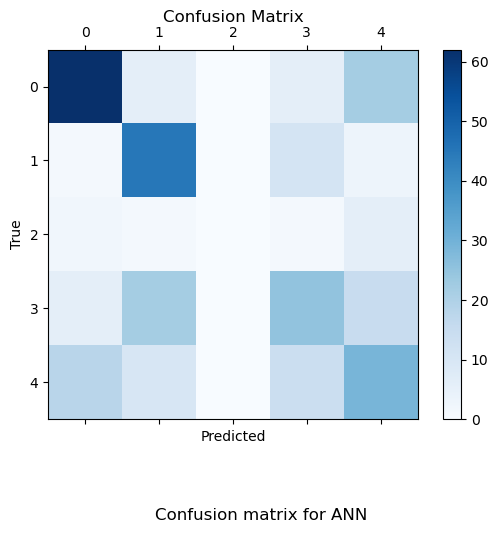

In [18]:
# --- Plotting the confusion matrix

y_non_oversampled = y.loc[non_oversampled_mask]
ann_pred = cv_predictions

fig, ax = plt.subplots()
cax = ax.matshow(confusion_matrix(y_no_oversample, ann_pred), cmap=plt.cm.Blues)
fig.colorbar(cax)

# labels and caption
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix', pad=20)
caption = "Confusion matrix for ANN"
plt.figtext(0.5, -0.1, caption, wrap=True, horizontalalignment='center', fontsize=12)

plt.show()

In [19]:

# complete the dataset
complete_dataset_type2('ann', model)

y = y.replace({0: 1, 1: 2, 2: 3, 3: 4, 4: 5})

## Random Forest

In [20]:
# --- Implementing a Random Forest Model

random_state = 123

# Split into train+CV and validation sets
non_oversampled_mask = train_dataset['oversampled'] == 'NO'
X_no_oversample = X[non_oversampled_mask]
y_no_oversample = y[non_oversampled_mask]


# Get oversampled data
X_oversample = X[train_dataset['oversampled'] == 'YES']
y_oversample = y[train_dataset['oversampled'] == 'YES']


rf_model = RandomForestClassifier(
    criterion='entropy',
    n_estimators=50,
    max_depth=20,
    min_samples_leaf=10,
    class_weight='balanced',
    random_state=random_state,
)

# Initialize cross-validation
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=random_state)

# Arrays for CV predictions
cv_predictions = np.zeros(len(X_no_oversample))
cv_probabilities = np.zeros((len(X_no_oversample), len(np.unique(y))))

# Perform cross-validation
for train_idx, cv_idx in skf.split(X_no_oversample, y_no_oversample):
    # Add oversampled data to training
    X_fold_train = pd.concat([X_no_oversample.iloc[train_idx], X_oversample])
    y_fold_train = pd.concat([y_no_oversample.iloc[train_idx], y_oversample])
    
    # Fit and predict
    rf_model.fit(X_fold_train, y_fold_train)
    cv_predictions[cv_idx] = rf_model.predict(X_no_oversample.iloc[cv_idx])
    cv_probabilities[cv_idx] = rf_model.predict_proba(X_no_oversample.iloc[cv_idx])

# Train final model on all train+CV data
X_final_train = pd.concat([X_no_oversample, X_oversample])
y_final_train = pd.concat([y_no_oversample, y_oversample])
rf_model.fit(X_final_train, y_final_train)


# Calculate scores
cv_f1 = f1_score(y_no_oversample, cv_predictions, average='macro')
results['rfc'] = cv_f1
print('Random Forest Results:')
print(f'Cross-validation F1: {cv_f1:.3f}')

IndexError: too many indices for tensor of dimension 2

In [ ]:
# --- Plotting the confusion matrix

y_non_oversampled = y.loc[non_oversampled_mask]
rfc_pred = cv_predictions

fig, ax = plt.subplots()
cax = ax.matshow(confusion_matrix(y_no_oversample, rfc_pred), cmap=plt.cm.Blues)
fig.colorbar(cax)

# labels and caption
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix', pad=20)
caption = "Confusion matrix for Random Forest Classifier"
plt.figtext(0.5, -0.1, caption, wrap=True, horizontalalignment='center', fontsize=12)

plt.show()

In [ ]:
# --- Completing the test dataset
complete_dataset('RandomForestClassifier', rf_model)

# SVM

In [ ]:
# --- Implementing a SVM model

random_state = 123

# Split into train+CV and validation sets
non_oversampled_mask = train_dataset['oversampled'] == 'NO'
X_no_oversample = X[non_oversampled_mask]
y_no_oversample = y[non_oversampled_mask]


# Get oversampled data
X_oversample = X[train_dataset['oversampled'] == 'YES']
y_oversample = y[train_dataset['oversampled'] == 'YES']


svm = SVC(
    random_state=random_state,
    class_weight='balanced',
    probability=True,
    kernel='rbf',
    C=1.0,
    gamma='scale',
)

# Initialize cross-validation
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=random_state)
# Arrays for CV predictions
cv_predictions = np.zeros(len(X_no_oversample))
cv_probabilities = np.zeros((len(X_no_oversample), len(np.unique(y))))

# Perform cross-validation
for train_idx, cv_idx in skf.split(X_no_oversample, y_no_oversample):
    # Add oversampled data to training
    X_fold_train = pd.concat([X_no_oversample.iloc[train_idx], X_oversample])
    y_fold_train = pd.concat([y_no_oversample.iloc[train_idx], y_oversample])
    
    # Fit and predict
    svm.fit(X_fold_train, y_fold_train)
    cv_predictions[cv_idx] = svm.predict(X_no_oversample.iloc[cv_idx])
    cv_probabilities[cv_idx] = svm.predict_proba(X_no_oversample.iloc[cv_idx])

# Train final model on all train+CV data
X_final_train = pd.concat([X_no_oversample, X_oversample])
y_final_train = pd.concat([y_no_oversample, y_oversample])
svm.fit(X_final_train, y_final_train)

# Calculate scores
cv_f1 = f1_score(y_no_oversample, cv_predictions, average='macro')
results['svm'] = cv_f1
print('SVM Results:')
print(f'Cross-validation F1: {cv_f1:.3f}')

In [ ]:
# --- Plotting the confusion matrix

y_non_oversampled = y.loc[non_oversampled_mask]
svm_pred = cv_predictions

fig, ax = plt.subplots()
cax = ax.matshow(confusion_matrix(y_no_oversample, svm_pred), cmap=plt.cm.Blues)
fig.colorbar(cax)

# labels and caption
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix', pad=20)
caption = "Confusion matrix for SVM"
plt.figtext(0.5, -0.1, caption, wrap=True, horizontalalignment='center', fontsize=12)

plt.show()

In [ ]:
# Complete the dataset
complete_dataset('svm', svm)

## XGBoost

In [ ]:
# --- Implementing an XGBoost model

# This specific model needs the target to be encoded starting from 0
y = y.replace({1: 0, 2: 1, 3: 2, 4: 3, 5: 4})

random_state = 123

# Split into train+CV and validation sets
non_oversampled_mask = train_dataset['oversampled'] == 'NO'
X_no_oversample = X[non_oversampled_mask]
y_no_oversample = y[non_oversampled_mask]


# Get oversampled data
X_oversample = X[train_dataset['oversampled'] == 'YES']
y_oversample = y[train_dataset['oversampled'] == 'YES']

xgbc = xgb.XGBClassifier(
    objective='multi:softprob',
    random_state=random_state,
    num_class=5,
    n_estimators=100,
    max_depth=3,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=3
)

# Initializing StratifiedKFold
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=random_state)

# Arrays for CV predictions
cv_predictions = np.zeros(len(X_no_oversample))
cv_probabilities = np.zeros((len(X_no_oversample), len(np.unique(y))))

# Perform cross-validation
for train_idx, cv_idx in skf.split(X_no_oversample, y_no_oversample):
    # Add oversampled data to training
    X_fold_train = pd.concat([X_no_oversample.iloc[train_idx], X_oversample])
    y_fold_train = pd.concat([y_no_oversample.iloc[train_idx], y_oversample])
    
    # Fit and predict
    xgbc.fit(X_fold_train, y_fold_train)
    cv_predictions[cv_idx] = xgbc.predict(X_no_oversample.iloc[cv_idx])
    cv_probabilities[cv_idx] = xgbc.predict_proba(X_no_oversample.iloc[cv_idx])

# Train final model on all train+CV data
X_final_train = pd.concat([X_no_oversample, X_oversample])
y_final_train = pd.concat([y_no_oversample, y_oversample])
xgbc.fit(X_final_train, y_final_train)


# Calculate scores
cv_f1 = f1_score(y_no_oversample, cv_predictions, average='macro')
results['xgbc'] = cv_f1
print('XGBoost Results:')
print(f'Cross-validation F1: {cv_f1:.3f}')



In [ ]:
# --- Plotting the confusion matrix

y_non_oversampled = y.loc[non_oversampled_mask]
xgb_pred = cv_predictions

fig, ax = plt.subplots()
cax = ax.matshow(confusion_matrix(y_no_oversample, xgb_pred), cmap=plt.cm.Blues)
fig.colorbar(cax)

# labels and caption
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix', pad=20)
caption = "Confusion matrix for XGBoost"
plt.figtext(0.5, -0.1, caption, wrap=True, horizontalalignment='center', fontsize=12)

plt.show()

In [ ]:

# Completing the test dataset
complete_dataset_type2('xgboost', xgbc)

y = y.replace({0: 1, 1: 2, 2: 3, 3: 4, 4: 5})

## Logistic Regression

In [ ]:
# --- Implementing a Logistic Regression model

random_state = 123

# Split into train+CV and validation sets
non_oversampled_mask = train_dataset['oversampled'] == 'NO'
X_no_oversample = X[non_oversampled_mask]
y_no_oversample = y[non_oversampled_mask]


# Get oversampled data
X_oversample = X[train_dataset['oversampled'] == 'YES']
y_oversample = y[train_dataset['oversampled'] == 'YES']


# Initializing the logistic regression model with pipeline
log_reg = LogisticRegression(
    random_state=random_state,
    max_iter=4000,
    class_weight='balanced',
    C=0.1,
    penalty='l1',
    solver='saga'  # needed for l1 penalty with multinomial
)

# Initialize cross-validation
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=random_state)

# Arrays for CV predictions
cv_predictions = np.zeros(len(X_no_oversample))
cv_probabilities = np.zeros((len(X_no_oversample), len(np.unique(y))))

# Perform cross-validation
for train_idx, cv_idx in skf.split(X_no_oversample, y_no_oversample):
    # Add oversampled data to training
    X_fold_train = pd.concat([X_no_oversample.iloc[train_idx], X_oversample])
    y_fold_train = pd.concat([y_no_oversample.iloc[train_idx], y_oversample])
    
    # Fit and predict
    log_reg.fit(X_fold_train, y_fold_train)
    cv_predictions[cv_idx] = log_reg.predict(X_no_oversample.iloc[cv_idx])
    cv_probabilities[cv_idx] = log_reg.predict_proba(X_no_oversample.iloc[cv_idx])

# Train final model on all train+CV data
X_final_train = pd.concat([X_no_oversample, X_oversample])
y_final_train = pd.concat([y_no_oversample, y_oversample])
log_reg.fit(X_final_train, y_final_train)


# Calculate scores
cv_f1 = f1_score(y_no_oversample, cv_predictions, average='macro')
results['logreg'] = cv_f1
print('Logistic Regression Results:')
print(f'Cross-validation F1: {cv_f1:.3f}')

In [ ]:
# --- Plotting the confusion matrix

y_non_oversampled = y.loc[non_oversampled_mask]
logreg_pred = cv_predictions

fig, ax = plt.subplots()
cax = ax.matshow(confusion_matrix(y_no_oversample, logreg_pred), cmap=plt.cm.Blues)
fig.colorbar(cax)

# labels and caption
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix', pad=20)
caption = "Confusion matrix for Logistic Regression"
plt.figtext(0.5, -0.1, caption, wrap=True, horizontalalignment='center', fontsize=12)

plt.show()

In [ ]:
# Complete the dataset
complete_dataset('logreg', log_reg)

# LightGBM

In [ ]:
# --- Implementing a LightGBM model
random_state = 123

# Split into train+CV and validation sets
non_oversampled_mask = train_dataset['oversampled'] == 'NO'
X_no_oversample = X[non_oversampled_mask]
y_no_oversample = y[non_oversampled_mask]


# Get oversampled data
X_oversample = X[train_dataset['oversampled'] == 'YES']
y_oversample = y[train_dataset['oversampled'] == 'YES']


lgbm = lgb.LGBMClassifier(
    objective='multiclass',
    random_state=random_state,
    num_class=5,
    n_estimators=100,
    max_depth=3,
    learning_rate=0.01,
    class_weight='balanced',
    min_child_samples=5,        # Lower minimum samples per leaf
    min_split_gain=0.0,        # Allow splits with smaller gains
    feature_fraction=0.8,       # Use only 80% of features per tree
    reg_alpha=0.1,             # L1 regularization
    reg_lambda=0.1,            # L2 regularization
    verbose=-1                  # Reduce verbosity
)

# Initialize cross-validation
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=random_state)

# Arrays for CV predictions
cv_predictions = np.zeros(len(X_no_oversample))
cv_probabilities = np.zeros((len(X_no_oversample), len(np.unique(y))))

# Perform cross-validation
for train_idx, cv_idx in skf.split(X_no_oversample, y_no_oversample):
    # Add oversampled data to training
    X_fold_train = pd.concat([X_no_oversample.iloc[train_idx], X_oversample])
    y_fold_train = pd.concat([y_no_oversample.iloc[train_idx], y_oversample])
    
    # Fit and predict
    lgbm.fit(X_fold_train, y_fold_train)
    cv_predictions[cv_idx] = lgbm.predict(X_no_oversample.iloc[cv_idx])
    cv_probabilities[cv_idx] = lgbm.predict_proba(X_no_oversample.iloc[cv_idx])

# Train final model on all train+CV data
X_final_train = pd.concat([X_no_oversample, X_oversample])
y_final_train = pd.concat([y_no_oversample, y_oversample])
lgbm.fit(X_final_train, y_final_train)


# Calculate scores
cv_f1 = f1_score(y_no_oversample, cv_predictions, average='macro')
results['lgbm'] = cv_f1
print('LightGBM Results:')
print(f'Cross-validation F1: {cv_f1:.3f}')

In [ ]:
# --- Plotting the confusion matrix

y_non_oversampled = y.loc[non_oversampled_mask]
lgbm_pred = cv_predictions

fig, ax = plt.subplots()
cax = ax.matshow(confusion_matrix(y_no_oversample, lgbm_pred), cmap=plt.cm.Blues)
fig.colorbar(cax)

# labels and caption
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix', pad=20)
caption = "Confusion matrix for LightGBM"
plt.figtext(0.5, -0.1, caption, wrap=True, horizontalalignment='center', fontsize=12)

plt.show()

In [ ]:
# Complete the dataset
complete_dataset('lightgbm', lgbm)

# Stacking Classifier

In [ ]:
# Cria o Stacking Classifier
stacking_model = StackingClassifier(
    estimators=[
        ('rfc', rf_model),
        ('xgboost', xgbc),
        ('svm', svm),
        ('lr', log_reg),
        ('lgbm', lgbm)
    ],
    final_estimator=LogisticRegression(
        class_weight='balanced',
        max_iter=1000,
        C=0.1
    ),  # Meta-modelo para combinar previsões
    cv=5
)

oversampling_indicator = train_dataset['oversampled']

# Getting indices of non-oversampled data
non_oversampled_indices = X[oversampling_indicator == 'NO'].index

# Initializing StratifiedKFold
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)

# Initializing array for storing predictions
predictions = np.zeros(len(non_oversampled_indices))
probabilities = np.zeros((len(non_oversampled_indices), 5))

# Performing cross-validation
for fold, (train_idx, val_idx) in enumerate(skf.split(
    X.loc[non_oversampled_indices],
    y.loc[non_oversampled_indices]
)):
    # Getting the actual indices
    actual_train_idx = non_oversampled_indices[train_idx]
    actual_val_idx = non_oversampled_indices[val_idx]
    
    # Add oversampled data to training set
    oversampled_indices = X[oversampling_indicator == 'YES'].index
    final_train_idx = np.concatenate([actual_train_idx, oversampled_indices])
    
    # Training model on combined data (original + oversampled)
    stacking_model.fit(
        X.loc[final_train_idx], 
        y.loc[final_train_idx],
    )
    
    # Predicting on validation set (non-oversampled only)
    val_pred = stacking_model.predict(X.loc[actual_val_idx])
    val_prob = stacking_model.predict_proba(X.loc[actual_val_idx])
    
    # Storing predictions
    predictions[val_idx] = val_pred
    probabilities[val_idx] = val_prob

# Calculating final scores
final_f1_macro = f1_score(y.loc[non_oversampled_indices], predictions, average='macro')
results['st']= final_f1_macro

print('\nFinal Stacking Results')
print(f'Overall Macro F1 Score: {final_f1_macro:.3f}')

In [ ]:
# --- Plotting the confusion matrix

y_non_oversampled = y.loc[non_oversampled_mask]
st1_pred = predictions

fig, ax = plt.subplots()
cax = ax.matshow(confusion_matrix(y_no_oversample, st1_pred), cmap=plt.cm.Blues)
fig.colorbar(cax)

# labels and caption
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix', pad=20)
caption = "Confusion matrix for Stacking1"
plt.figtext(0.5, -0.1, caption, wrap=True, horizontalalignment='center', fontsize=12)

plt.show()

In [ ]:
# Complete the dataset
complete_dataset('stacking', stacking_model)

# Stacking Classifier 2

In [ ]:
# Cria o Stacking Classifier
stacking_model_2 = StackingClassifier(
    estimators=[
        ('rfc', rf_model),
        ('xgboost', xgbc),
        ('lgbm', lgbm)
    ],
    final_estimator=LogisticRegression(
        class_weight='balanced',
        max_iter=1000,
        C=0.1
    ),  # Meta-modelo para combinar previsões
    cv=5
)

oversampling_indicator = train_dataset['oversampled']

# Getting indices of non-oversampled data
non_oversampled_indices = X[oversampling_indicator == 'NO'].index

# Initializing StratifiedKFold
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)

# Initializing array for storing predictions
predictions = np.zeros(len(non_oversampled_indices))
probabilities = np.zeros((len(non_oversampled_indices), 5))

# Performing cross-validation
for fold, (train_idx, val_idx) in enumerate(skf.split(
    X.loc[non_oversampled_indices],
    y.loc[non_oversampled_indices]
)):
    # Getting the actual indices
    actual_train_idx = non_oversampled_indices[train_idx]
    actual_val_idx = non_oversampled_indices[val_idx]
    
    # Add oversampled data to training set
    oversampled_indices = X[oversampling_indicator == 'YES'].index
    final_train_idx = np.concatenate([actual_train_idx, oversampled_indices])
    
    # Training model on combined data (original + oversampled)
    stacking_model_2.fit(
        X.loc[final_train_idx], 
        y.loc[final_train_idx],
    )
    
    # Predicting on validation set (non-oversampled only)
    val_pred = stacking_model_2.predict(X.loc[actual_val_idx])
    val_prob = stacking_model_2.predict_proba(X.loc[actual_val_idx])
    
    # Storing predictions
    predictions[val_idx] = val_pred
    probabilities[val_idx] = val_prob

# Calculating final scores
final_f1_macro = f1_score(y.loc[non_oversampled_indices], predictions, average='macro')
results['st2']= final_f1_macro

print('\nFinal Stacking 2 Results')
print(f'Overall Macro F1 Score: {final_f1_macro:.3f}')

In [ ]:
# --- Plotting the confusion matrix

y_non_oversampled = y.loc[non_oversampled_mask]
st2_pred = predictions

fig, ax = plt.subplots()
cax = ax.matshow(confusion_matrix(y_no_oversample, st2_pred), cmap=plt.cm.Blues)
fig.colorbar(cax)

# labels and caption
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix', pad=20)
caption = "Confusion matrix for Stacking2"
plt.figtext(0.5, -0.1, caption, wrap=True, horizontalalignment='center', fontsize=12)

plt.show()

In [ ]:
# Complete the dataset
complete_dataset('stacking2', stacking_model_2)

# Voting Classifier

In [ ]:
# Cria o Voting Classifier
voting_model = VotingClassifier(
    estimators=[
        ('rfc', rf_model),
        ('xgboost', xgbc),
        ('svm', svm),
        ('lr', log_reg),
        ('lgbm', lgbm)
    ],
    voting='soft'  # ou 'hard' para votação majoritária
)

oversampling_indicator = train_dataset['oversampled']

# Getting indices of non-oversampled data
non_oversampled_indices = X[oversampling_indicator == 'NO'].index

# Initializing StratifiedKFold
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)

# Initializing array for storing predictions
predictions = np.zeros(len(non_oversampled_indices))
probabilities = np.zeros((len(non_oversampled_indices), 5))

# Performing cross-validation
for fold, (train_idx, val_idx) in enumerate(skf.split(
    X.loc[non_oversampled_indices],
    y.loc[non_oversampled_indices]
)):
    # Getting the actual indices
    actual_train_idx = non_oversampled_indices[train_idx]
    actual_val_idx = non_oversampled_indices[val_idx]
    
    # Add oversampled data to training set
    oversampled_indices = X[oversampling_indicator == 'YES'].index
    final_train_idx = np.concatenate([actual_train_idx, oversampled_indices])
    
    # Training model on combined data (original + oversampled)
    voting_model.fit(
        X.loc[final_train_idx], 
        y.loc[final_train_idx],
    )
    
    # Predicting on validation set (non-oversampled only)
    val_pred = voting_model.predict(X.loc[actual_val_idx])
    val_prob = voting_model.predict_proba(X.loc[actual_val_idx])
    
    # Storing predictions
    predictions[val_idx] = val_pred
    probabilities[val_idx] = val_prob
    
# Calculating final scores
final_f1_macro = f1_score(y.loc[non_oversampled_indices], predictions, average='macro')
results['vote']= final_f1_macro

print('\nFinal Voting Results')
print(f'Overall Macro F1 Score: {final_f1_macro:.3f}')

In [ ]:
# --- Plotting the confusion matrix

y_non_oversampled = y.loc[non_oversampled_mask]
voting1_pred = predictions

fig, ax = plt.subplots()
cax = ax.matshow(confusion_matrix(y_no_oversample, voting1_pred), cmap=plt.cm.Blues)
fig.colorbar(cax)

# labels and caption
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix', pad=20)
caption = "Confusion matrix for Voting1"
plt.figtext(0.5, -0.1, caption, wrap=True, horizontalalignment='center', fontsize=12)

plt.show()

In [ ]:
# Complete the dataset
complete_dataset('voting', voting_model)

# Voting Classifier 2

In [ ]:
# Cria o Voting Classifier
voting_model_2 = VotingClassifier(
    estimators=[
        ('rfc', rf_model),
        ('xgboost', xgbc),
        ('lgbm', lgbm)
    ],
    voting='soft'  # ou 'hard' para votação majoritária
)

oversampling_indicator = train_dataset['oversampled']

# Getting indices of non-oversampled data
non_oversampled_indices = X[oversampling_indicator == 'NO'].index

# Initializing StratifiedKFold
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)

# Initializing array for storing predictions
predictions = np.zeros(len(non_oversampled_indices))
probabilities = np.zeros((len(non_oversampled_indices), 5))

# Performing cross-validation
for fold, (train_idx, val_idx) in enumerate(skf.split(
    X.loc[non_oversampled_indices],
    y.loc[non_oversampled_indices]
)):
    # Getting the actual indices
    actual_train_idx = non_oversampled_indices[train_idx]
    actual_val_idx = non_oversampled_indices[val_idx]
    
    # Add oversampled data to training set
    oversampled_indices = X[oversampling_indicator == 'YES'].index
    final_train_idx = np.concatenate([actual_train_idx, oversampled_indices])
    
    # Training model on combined data (original + oversampled)
    voting_model_2.fit(
        X.loc[final_train_idx], 
        y.loc[final_train_idx],
    )
    
    # Predicting on validation set (non-oversampled only)
    val_pred = voting_model_2.predict(X.loc[actual_val_idx])
    val_prob = voting_model_2.predict_proba(X.loc[actual_val_idx])
    
    # Storing predictions
    predictions[val_idx] = val_pred
    probabilities[val_idx] = val_prob
    
# Calculating final scores
final_f1_macro = f1_score(y.loc[non_oversampled_indices], predictions, average='macro')
results['vote2']= final_f1_macro

print('\nFinal Voting 2 Results')
print(f'Overall Macro F1 Score: {final_f1_macro:.3f}')

In [ ]:
# --- Plotting the confusion matrix

y_non_oversampled = y.loc[non_oversampled_mask]
voting2_pred = predictions

fig, ax = plt.subplots()
cax = ax.matshow(confusion_matrix(y_no_oversample, voting2_pred), cmap=plt.cm.Blues)
fig.colorbar(cax)

# labels and caption
plt.xlabel('Predicted') 
plt.ylabel('True')
plt.title('Confusion Matrix', pad=20)
caption = "Confusion matrix for Voting2"
plt.figtext(0.5, -0.1, caption, wrap=True, horizontalalignment='center', fontsize=12)

plt.show()

In [ ]:
# Complete the dataset
complete_dataset('voting2', voting_model)

# Resultados de cada Modelo

In [ ]:
for model in results:
    print(f"Modelo: {model} - Score: {results[model]}")

In [ ]:
fig = plt.figure(figsize = (10, 5))

mod = results.keys()
acc = results.values()

plt.bar(mod, acc, color='skyblue', width = 0.5)
 
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.title("Models accuracy comparison")

plt.show()